In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from appF_diagnostic import *

In [2]:
DEVICE = 'cpu'
n = 512
# aspect_ratio = 4
# spectrum = torch.cat((
#     torch.logspace(0, -2, steps=n//2, dtype=torch.float64),
#     torch.zeros(n - n//2, dtype=torch.float64),
# ))
spectrum = torch.logspace(-0.01, -8, steps=n, dtype=torch.float64, device=DEVICE)
assert torch.all(spectrum[:-1] >= spectrum[1:]), "spectrum must be decreasing"
# G = spectrum2matrix(spectrum, aspect_ratio)

G = torch.diag(spectrum)

PE = PolarExpressDiagnostic(coeffs_name='ns3', steps=10, restarts=[2], sym_mm_name='avg')
_, diagnostics = PE(G)
df = pd.DataFrame(diagnostics)

In [3]:
list(df)

['R_eigvals',
 'R_min_eigval',
 'R_max_eigval',
 'R_eigvals_from_starting_vecs',
 'R_min_eigval_from_starting_vecs',
 'R_max_eigval_from_starting_vecs',
 'R_largest_entry',
 'Z_eigvals',
 'Z_min_eigval',
 'Z_max_eigval',
 'Z_eigvals_from_starting_vecs',
 'Z_min_eigval_from_starting_vecs',
 'Z_max_eigval_from_starting_vecs',
 'Z_largest_entry',
 'Q_eigvals',
 'Q_min_eigval',
 'Q_max_eigval',
 'Q_eigvals_from_starting_vecs',
 'Q_min_eigval_from_starting_vecs',
 'Q_max_eigval_from_starting_vecs',
 'Q_largest_entry',
 'X_eigvals',
 'X_min_eigval',
 'X_max_eigval',
 'X_eigvals_from_starting_vecs',
 'X_min_eigval_from_starting_vecs',
 'X_max_eigval_from_starting_vecs',
 'X_largest_entry',
 'orth_error',
 'residual_error',
 'psd_error',
 'dual_obj',
 'bound_violation']

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

spectrum_cpu = spectrum.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
columns = ['R_eigvals_from_starting_vecs', 'Z_eigvals_from_starting_vecs', 'Q_eigvals_from_starting_vecs', 'X_eigvals_from_starting_vecs']
# columns = ['R_eigvals', 'Z_eigvals', 'Q_eigvals']
titles = ['R eigvals', 'Z eigvals', 'Q eigvals', 'X eigvals']
all_lines = {col: [] for col in columns}

def init():
    ret = []
    for ax, col, title, fun in zip(axes, columns, titles, (lambda x: np.ones_like(x), lambda x: np.ones_like(x), lambda x: 1/x,)):
        line, = ax.plot(spectrum_cpu, fun(spectrum_cpu), color='black', linestyle='dashed', linewidth=0.5)
        all_lines[col].append(line)
        ret.extend(all_lines[col])
    return ret

def update(frame):
    ret = []
    for ax, col, title in zip(axes, columns, titles):
        vals = df[col].iloc[frame]
        line, = ax.plot(spectrum_cpu, vals, label=f'step {frame}')
        all_lines[col].append(line)
        ax.set_title(f'{title} (steps 0 – {frame})')
        ax.set_xlabel('X_0 eigenvalues')
        ax.legend(loc='upper right', fontsize='small')
        ret.extend(all_lines[col])
    return ret

ani = FuncAnimation(fig, update, frames=len(df), init_func=lambda: [], interval=500, repeat=False)
plt.close(fig)
HTML(ani.to_jshtml())

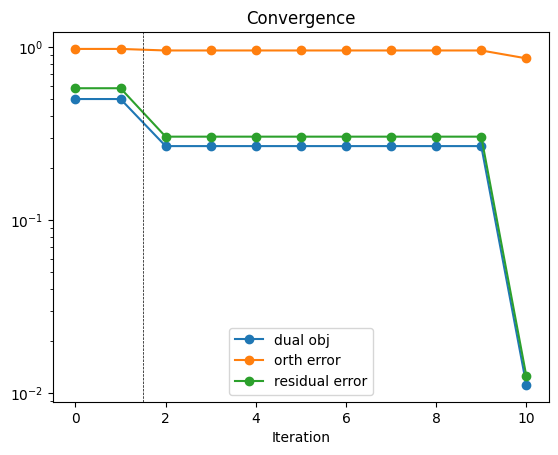

In [6]:
plt.plot(df['dual_obj'], marker='o', label='dual obj')
plt.plot(df['orth_error'], marker='o', label='orth error')
plt.plot(df['residual_error'], marker='o', label='residual error')
for restart in PE.restarts:
    plt.axvline(x=restart-0.5, color='black', linestyle='dashed', linewidth=0.5)
plt.title("Convergence")
plt.xlabel('Iteration')
plt.yscale('log')
plt.legend()